#Predicción de Precios de Vehículos Usados (Core)

Implementar y evaluar modelos de regresión, y seleccionar el mejor modelo basado en las métricas de evaluación.



##Requisitos

1.  Carga y Exploración de Datos:

* Descargar y cargar el dataset.
* Realizar una exploración inicial para entender la estructura del dataset.
* Identificar valores faltantes, duplicados y outliers.

2.  Limpieza y Preprocesamiento:

* Manejar valores faltantes.
* Eliminar duplicados.
* Corregir inconsistencias en los datos categóricos.
* Escalar las características numéricas.
* Realizar transformaciones necesarias para las características categóricas.

3.  Exploración de Datos:

* Crear visualizaciones univariadas y multivariadas.
* Calcular estadísticas descriptivas.

4.  Modelado y Evaluación:

* Implementar al menos dos modelos de regresión (Linear Regression y Random Forest Regressor).
* Evaluar los modelos utilizando MSE, RMSE, y R^2.
* Seleccionar el mejor modelo basado en las métricas de evaluación.

5.  Optimización del Modelo:

* Optimizar el modelo seleccionado utilizando GridSearchCV.

6.  Documentación y Entrega:

* Documentar todo el proceso en un archivo .ipynb claramente comentado.
* Crear visualizaciones con interpretaciones.
* Subir el archivo a un repositorio en GitHub con un tag de liberación.
Dataset:

Used Cars Dataset
[Aqui](https://www.kaggle.com/austinreese/craigslist-carstrucks-data/)

##Desarrollo

In [ ]:
!pip install lazypredict --quiet

###Importar de Liberias.

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

###Carga de DataSet

In [ ]:
# Definimos solo las columnas que nos interesan y están limpias en su mayoria
columnas_limpias = ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color' , 'state', 'posting_date']

df = pd.read_csv(
    'vehicles.csv',
    usecols=columnas_limpias,
    on_bad_lines='skip', # Ignora las filas mal formadas
    engine='python' # Usa el motor de Python para una mejor gestión de errores de parsing
)


En primera instancia no se pudo cargar el dataset, estio debido a caracteres que generan error el la carga, tras analizar el DataSet en el sitio web de descarga, se tomo la desicion de seleccionar previamente  las columnas a considerar  ya que existe  columnas que no  son utilis para el anilisi y modelo.

Dimensiones del DataSet

In [ ]:
df.shape

(3368, 17)

In [ ]:
df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [ ]:
df.tail()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
3363,huntsville / decatur,18199,2018.0,nissan,maxima,NaN,NaN,gas,101821.0,clean,automatic,fwd,NaN,sedan,silver,al,2021-04-16T15:00:52-0500
3364,huntsville / decatur,45500,1955.0,chevrolet,belair,excellent,8 cylinders,gas,15000.0,clean,automatic,rwd,full-size,coupe,red,al,2021-04-16T14:57:27-0500
3365,huntsville / decatur,24995,2012.0,ford,f250 xl super duty,NaN,NaN,gas,52377.0,clean,automatic,NaN,NaN,NaN,grey,al,2021-04-16T14:31:53-0500
3366,huntsville / decatur,29988,2007.0,gmc,c8500,excellent,6 cylinders,diesel,163063.0,clean,automatic,rwd,full-size,truck,white,al,2021-04-16T14:14:24-0500
3367,huntsville / decatur,12989,2013.0,cadillac,cts sedan,NaN,6 cylinders,NaN,73857.0,clean,automatic,rwd,NaN,sedan,NaN,al,2021-04-16T14:11:00-0500


###Informacion del DataFrame

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3368 entries, 0 to 3367
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region        3368 non-null   object 
 1   price         3368 non-null   int64  
 2   year          3299 non-null   float64
 3   manufacturer  3133 non-null   object 
 4   model         3315 non-null   object 
 5   condition     1950 non-null   object 
 6   cylinders     2018 non-null   object 
 7   fuel          3285 non-null   object 
 8   odometer      3329 non-null   float64
 9   title_status  3219 non-null   object 
 10  transmission  3339 non-null   object 
 11  drive         2147 non-null   object 
 12  size          740 non-null    object 
 13  type          2384 non-null   object 
 14  paint_color   2571 non-null   object 
 15  state         3368 non-null   object 
 16  posting_date  3341 non-null   object 
dtypes: float64(2), int64(1), object(14)
memory usage: 447.4+ KB


### Estadisticas Descriptiva

In [ ]:
df.describe()

,price,year,odometer
count,3.368000e+03,3299.000000,3.329000e+03
mean,3.429271e+05,2011.548045,1.562001e+05
std,1.710454e+07,9.836676,7.647996e+05
min,0.000000e+00,1903.000000,0.000000e+00
25%,6.980000e+03,2008.000000,2.932200e+04
50%,1.912800e+04,2014.000000,8.046500e+04
75%,2.999000e+04,2017.000000,1.471240e+05
max,9.876543e+08,2021.000000,9.999999e+06


###Tipos de Datos

In [ ]:
print(df.dtypes)

region           object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
size             object
type             object
paint_color      object
state            object
posting_date     object
dtype: object


### Valores Únicos para todas las columnas

In [ ]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'size', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [ ]:
for column in df.columns:
    print(f"Valores únicos en la columna '{column}':")
    print(df[column].unique())
    print("\n" + "-" * 30 + "\n")

Valores únicos en la columna 'region':
['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham' 'skagit / island / SJI' 'la crosse' 'auburn' 'birmingham'
 'dothan' 'florence / muscle shoals' 'gadsden-anniston'
 'huntsville / decatur']

------------------------------

Valores únicos en la columna 'price':
[     6000     11900     21000      1500      4900      1600      1000
     15995      5000      3000         0     13995     24999     21850
     26850     11999       500     33590     22590     39590     30990
     15000     27990     34590     35000     29990     38590      4500
     32990     24590     37990     30590     38990     31590     19900
     16590     26990     25590     14000     28590     25990     34990
     22500     31990     23990     22990     33990     26590     18590
     29590     21590     37590     28990     36990     19990      2100
        80     15990     20590     12

La columna cylinders posee datos  del tipo string, para mejor interpretacion de los datos los datos unicos de estan columnas seran cambiado solamente por el numero de cilindros y luego se procederá al cambio de tipo de variable  de esta y las siguientes columnas 'year', 'cylinders'  a INT y la columna 'posting_date' a Date.





###Normalizacion de Datos

In [ ]:

mapping_cylinders = {
    '12 cylinders': 12,
    '10 cylinders': 10,
    '8 cylinders': 8,
    '6 cylinders': 6,
    '5 cylinders': 5,
    '4 cylinders': 4,
    '3 cylinders': 3,
    'other': 0
}

# Aplicamos los cambios al DataFrame
df['cylinders'] = df['cylinders'].map(mapping_cylinders)

In [ ]:
df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [ ]:
df.tail()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
3363,huntsville / decatur,18199,2018.0,nissan,maxima,NaN,NaN,gas,101821.0,clean,automatic,fwd,NaN,sedan,silver,al,2021-04-16T15:00:52-0500
3364,huntsville / decatur,45500,1955.0,chevrolet,belair,excellent,8.0,gas,15000.0,clean,automatic,rwd,full-size,coupe,red,al,2021-04-16T14:57:27-0500
3365,huntsville / decatur,24995,2012.0,ford,f250 xl super duty,NaN,NaN,gas,52377.0,clean,automatic,NaN,NaN,NaN,grey,al,2021-04-16T14:31:53-0500
3366,huntsville / decatur,29988,2007.0,gmc,c8500,excellent,6.0,diesel,163063.0,clean,automatic,rwd,full-size,truck,white,al,2021-04-16T14:14:24-0500
3367,huntsville / decatur,12989,2013.0,cadillac,cts sedan,NaN,6.0,NaN,73857.0,clean,automatic,rwd,NaN,sedan,NaN,al,2021-04-16T14:11:00-0500


###Datos Nulos

In [ ]:
# Imprime un mensaje indicando que se mostrará la cantidad de valores nulos presentes en
# cada columna del DataFrame
print("Cantidad de valores nulos por columna:")

# Calcula y muestra la cantidad de valores nulos por columna en el DataFrame
# 'df' Utiliza 'isnull()' para identificar los valores nulos y 'sum()' para
# contar cuántos hay en cada columna.
print(df.isnull().sum())

Cantidad de valores nulos por columna:
region             0
price              0
year              69
manufacturer     235
model             53
condition       1418
cylinders       1350
fuel              83
odometer          39
title_status     149
transmission      29
drive           1221
size            2628
type             984
paint_color      797
state              0
posting_date      27
dtype: int64


### Imputación de Valores Faltantes

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral
size,2628,78.03,Eliminar columna (> 50%)
condition,1418,42.10,Evaluar (30-50%)
cylinders,1350,40.08,Evaluar (30-50%)
drive,1221,36.25,Evaluar (30-50%)
type,984,29.22,Imputar (< 30%)
paint_color,797,23.66,Imputar (< 30%)
manufacturer,235,6.98,Imputar (< 30%)
title_status,149,4.42,Imputar (< 30%)
fuel,83,2.46,Imputar (< 30%)
year,69,2.05,Imputar (< 30%)


In [ ]:
columnas_a_eliminar = ['size']
df = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

el porcentaje de datos faltantes  en la columna size se vuelve inmanejable por lo cual se toma la desicion de eliminar.

In [ ]:
# Definimos los niveles de especificidad para rescatar los datos faltantes
jerarquias = [
    ['manufacturer', 'model', 'year'], # Nivel 1: Muy específico
    ['manufacturer', 'model'],          # Nivel 2: Específico
    ['manufacturer'],                   # Nivel 3: Genérico por marca
    []                                  # Nivel 4: Respaldo global
]

# Aseguramos que las columnas de anclaje para agrupar no tengan nulos intermedios
columnas_ancla = ['manufacturer', 'model', 'year']
for col in columnas_ancla:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('unknown')
        else:
            df[col] = df[col].fillna(df[col].median())

el uso de jerarquias de de grupos y tecnica de imputacion de los datos es una sugerencia de modelos LLM, esto  con el fin de crear un algoritmo mas flexible al momento de imputar los datos faltantes

In [ ]:
# Columnas donde calcularemos la MEDIANA (Numéricas)
cols_numericas = ['cylinders', 'odometer']

# Columnas donde calcularemos la MODA (Categorizaciones/Texto)
cols_categoricas = [
    'condition', 'drive', 'paint_color', 'type',
    'title_status', 'fuel', 'transmission'
]

se crearon  2  variables una con las columnas numericas y otro con las variable categoricas, esto ya que se aplicara la mismatecnic para las numericas "mediana" y para las categoricas "Moda".

In [ ]:
# Imputación de Variables Numéricas (Mediana)
for col in cols_numericas:
    if col in df.columns:
        for nivel in jerarquias:
            if df[col].isna().sum() == 0:
                break
            if nivel:
                # Filtrar solo elementos válidos del nivel
                # Una columna es válida para agrupar si existe y no es completamente "desconocida" (para tipos de objetos).
                nivel_valido = [c for c in nivel if c in df.columns and not (df[c].dtype == 'object' and (df[c] == 'unknown').all())]
                if nivel_valido: # Solo intente agrupar si hay columnas válidas para agrupar.
                    mediana_grupo = df.groupby(nivel_valido)[col].transform('median')
                    df[col] = df[col].fillna(mediana_grupo)
            else:
                # If nivel is empty (global median level)
                df[col] = df[col].fillna(df[col].median())

        # Cierre forzado de seguridad a entero
        # Esta línea rellena cualquier NaN restante con la mediana global y lo convierte a entero.
        # # Debe aplicarse después de todos los intentos de imputación jerárquica.

        df[col] = df[col].fillna(df[col].median()).astype(int)

Este bloque de código replica la misma lógica de imputación en cascada, adaptada específicamente para variables numéricas (como el precio, el año o el kilometraje). Además, introduce dos capas críticas el uso de la mediana (en lugar de la moda) y una validación dinámica de las columnas de agrupación.

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral
condition,1418,42.10,Evaluar (30-50%)
drive,1221,36.25,Evaluar (30-50%)
type,984,29.22,Imputar (< 30%)
paint_color,797,23.66,Imputar (< 30%)
title_status,149,4.42,Imputar (< 30%)
fuel,83,2.46,Imputar (< 30%)
transmission,29,0.86,Imputar (< 30%)
posting_date,27,0.80,Imputar (< 30%)


In [ ]:
# Imputación de Variables Categoricas (Moda)
for col in cols_categoricas:
    if col in df.columns:
        # Asegurar tipo string para evitar conflictos de tipos mixtos
        df[col] = df[col].astype(str).replace('nan', np.nan)

        for nivel in jerarquias:
            if df[col].isna().sum() == 0:
                break
            if nivel:
                # Usamos una función lambda para extraer la moda de forma segura por grupo
                try:
                    moda_grupo = df.groupby(nivel)[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
                    df[col] = df[col].fillna(moda_grupo)
                except:
                    continue
            else:
                # Respaldo con la moda global si la cascada no encuentra coincidencias
                if not df[col].mode().empty:
                    df[col] = df[col].fillna(df[col].mode()[0])

        # Si aún queda algún rezagado, asignamos una etiqueta genérica limpia
        df[col] = df[col].fillna('not_specified')

Este fragmento de código implementa una estrategia de imputación por moda en cascada (o jerárquica) para variables categóricas. Su objetivo es rellenar los valores faltantes (NaN) de una manera inteligente, en lugar de usar una moda global para todo el dataset (lo cual introduciría mucho sesgo), intenta calcular la moda basándose en grupos organizados por niveles de jerarquía de negocio.

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral
posting_date,27,0.8,Imputar (< 30%)


In [ ]:
# Caso Especial: 'posting_date' (Fecha)
if 'posting_date' in df.columns:
    df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
    # Imputamos fechas faltantes con la técnica de "Foward Fill" (propagación de la última fecha válida)
    df['posting_date'] = df['posting_date'].ffill().bfill()

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral


Este bloque de código se encarga del tratamiento y la limpieza de la columna posting_date (que representa la fecha de publicación del anuncio del vehículo). Trabaja con dos de los problemas más comunes al procesar fechas, la conversión de tipos de datos incorrectos y la gestión de valores faltantes (nulos) mediante continuidad temporal.

In [ ]:
df.head(5)

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date
0,prescott,6000,2014.0,unknown,unknown,good,6,gas,46973,clean,automatic,rwd,truck,white,az,2021-05-04 12:31:18-05:00
1,fayetteville,11900,2014.0,unknown,unknown,good,6,gas,46973,clean,automatic,rwd,truck,white,ar,2021-05-04 12:31:18-05:00
2,florida keys,21000,2014.0,unknown,unknown,good,6,gas,46973,clean,automatic,rwd,truck,white,fl,2021-05-04 12:31:18-05:00
3,worcester / central MA,1500,2014.0,unknown,unknown,good,6,gas,46973,clean,automatic,rwd,truck,white,ma,2021-05-04 12:31:18-05:00
4,greensboro,4900,2014.0,unknown,unknown,good,6,gas,46973,clean,automatic,rwd,truck,white,nc,2021-05-04 12:31:18-05:00


In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral


###Verificacion Tipo de Dato



In [ ]:
print(df.dtypes)

region                             object
price                               int64
year                              float64
manufacturer                       object
model                              object
condition                          object
cylinders                           int64
fuel                               object
odometer                            int64
title_status                       object
transmission                       object
drive                              object
type                               object
paint_color                        object
state                              object
posting_date    datetime64[ns, UTC-05:00]
dtype: object


In [ ]:
df.describe()

,price,year,cylinders,odometer
count,3.368000e+03,3368.000000,3368.00000,3.368000e+03
mean,3.429271e+05,2011.598278,6.15380,1.551769e+05
std,1.710454e+07,9.741559,1.56915,7.604274e+05
min,0.000000e+00,1903.000000,0.00000,0.000000e+00
25%,6.980000e+03,2009.000000,6.00000,2.949900e+04
50%,1.912800e+04,2014.000000,6.00000,8.022750e+04
75%,2.999000e+04,2017.000000,8.00000,1.468342e+05
max,9.876543e+08,2021.000000,12.00000,9.999999e+06


In [ ]:
# Calcular Q1 (percentil 25) y Q3 (percentil 75)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar (Eliminar) los outliers del DataFrame
df_limpio = df[(df['price'] >= limite_inferior) & (df['price'] <= limite_superior)]

In [ ]:
df_limpio.shape

(3346, 16)

In [ ]:
df = df_limpio.copy()

In [ ]:
df.shape

(3346, 16)

###Visualizacion Exploratoria

In [ ]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

####Evolución del Precio Mediano según el Año del Vehículo (Curva de Depreciación)

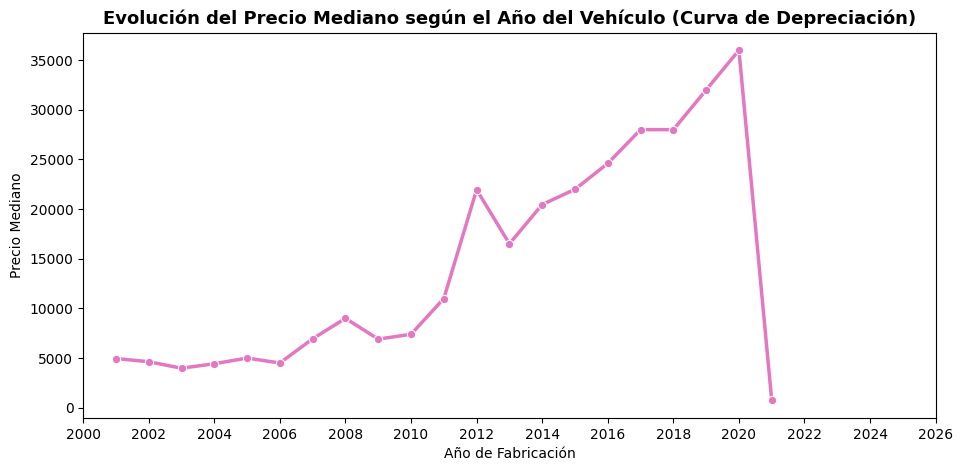

In [ ]:
fig1 = plt.figure(figsize=(11, 5))

# Filtrar años razonables para evitar errores de datos históricos residuales
df_historico = df[(df['year'] > 2000) & (df['year'] <= 2026)]

# Agrupamos por año y calculamos la mediana del precio
evolucion_precio = df_historico.groupby('year')['price'].median().reset_index()

sns.lineplot(
    data=evolucion_precio,
    x='year',
    y='price',
    marker='o',         # Añade un punto en cada año
    linewidth=2.5,
    color='#e377c2'
)

plt.title('Evolución del Precio Mediano según el Año del Vehículo (Curva de Depreciación)', fontsize=13, fontweight='bold')
plt.xlabel('Año de Fabricación')
plt.ylabel('Precio Mediano')
plt.xticks(range(2000, 2027, 2)) # Ajusta marcas en el eje X cada 2 años
plt.show()

fig1.savefig('grafico1.png', dpi=300, bbox_inches='tight')
plt.close(fig1)

El grafico muestra como los vehiculos mas reciente presentan precio mas elevados, el hecho de los valores para los años 2021 y 2022 caigan no es por un hecho de devaloracion de los vehiculos, si no la falta de datos de esos años.

####Precio Mediano de Venta por Marca (Top 15 marcas más frecuentes)

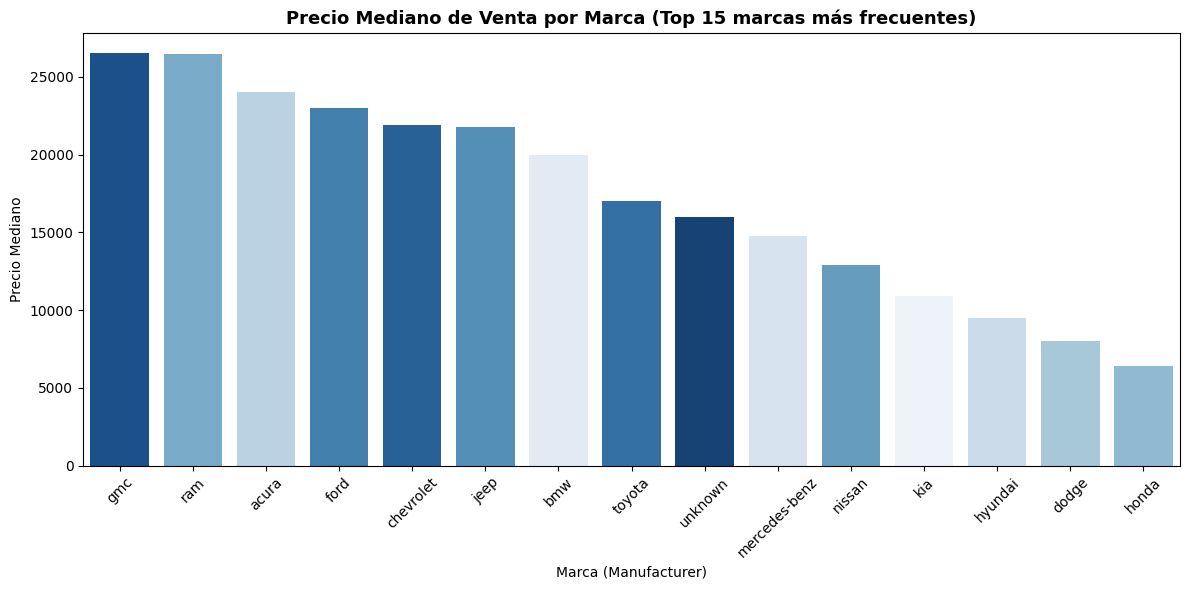

In [ ]:
fig = plt.figure(figsize=(12, 6))

# Filtrar las 15 marcas más frecuentes para no saturar el gráfico
top_marcas = df['manufacturer'].value_counts().head(15).index
df_top = df[df['manufacturer'].isin(top_marcas)]

# Calcular el orden basado en la mediana de precio de cada marca
orden_marcas = df_top.groupby('manufacturer')['price'].median().sort_values(ascending=False).index

sns.barplot(
    data=df_top,
    x='manufacturer',
    y='price',
    hue='manufacturer', # Explicitly assign hue to silence Future Warning
    order=orden_marcas,
    estimator='median', # Forzamos a que la altura de la barra sea la MEDIANA, no el promedio
    errorbar=None,       # Elimina las barras de error para una visualización más limpia
    palette='Blues_r',
    legend=False # Set legend=False since hue is assigned to x-axis variable
)

plt.title('Precio Mediano de Venta por Marca (Top 15 marcas más frecuentes)', fontsize=13, fontweight='bold')
plt.xlabel('Marca (Manufacturer)')
plt.ylabel('Precio Mediano')
plt.xticks(rotation=45) # Rota los nombres para que no se traslapen
plt.tight_layout()
plt.show()

fig.savefig('grafico2.png', dpi=300, bbox_inches='tight')
plt.close(fig)

El gráfico es excelente para demostrar cómo el tipo de vehículo que fabrica una marca (como las camionetas de Ram) afecta drásticamente a su valor mediano en el mercado de usados, incluso por encima de las marcas de lujo tradicionales.

####Distribución del Mercado: Precio versus Cantidad de Vehículos

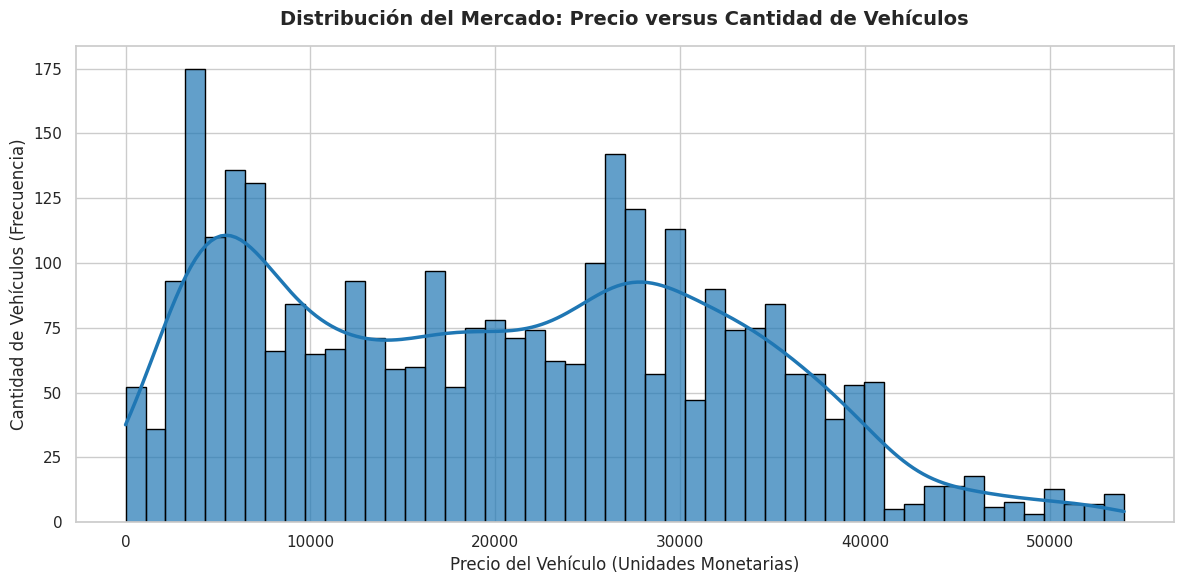

In [ ]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 6))

limite_superior = df['price'].quantile(0.99)
df_filtrado = df[(df['price'] > 0) & (df['price'] <= limite_superior)]

# 3. Creación del Histograma de Precio versus Cantidad
sns.histplot(
    data=df_filtrado,
    x='price',
    bins=50,                  # Cantidad de barras/intervalos de precio
    kde=True,                 # Añade la curva de estimación de densidad
    color='#1f77b4',          # Color azul corporativo
    alpha=0.7,                # Transparencia de las barras
    edgecolor='black',        # Borde de las barras para mayor definición
    line_kws={'linewidth': 2.5, 'color': '#d62728'} # Configuración de la curva (Roja)
)

# 4. Personalización de etiquetas y títulos del gráfico
plt.title('Distribución del Mercado: Precio versus Cantidad de Vehículos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio del Vehículo (Unidades Monetarias)', fontsize=12)
plt.ylabel('Cantidad de Vehículos (Frecuencia)', fontsize=12)

# 5. Ajustar el diseño y mostrar la visualización
plt.tight_layout()
plt.show()
fig.savefig('grafico3.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Este gráfico presenta una forma muy clásica en la economía de bienes de consumo (conocida como asimetría a la derecha). Esto significa que la gran mayoría de los datos se concentran al principio y luego se van "estirando" en una cola larga hacia los precios más altos. Esto demuestra que el grueso del mercado de usados está compuesto por autos accesibles. Es donde se mueve la mayor cantidad de compradores y donde hay más oferta disponible.

####Detección Visual de Outliers en el Precio de los Vehículos

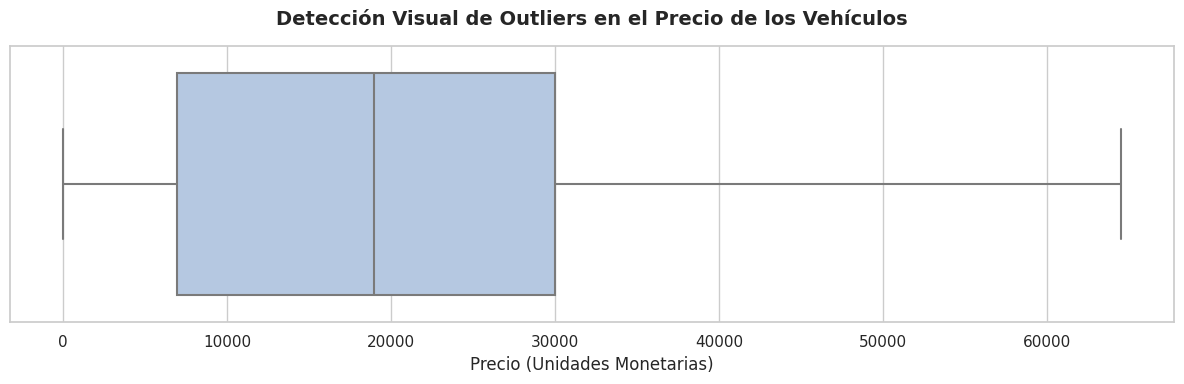

In [ ]:
# 1. Configuración del estilo visual
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 4))

# 2. Generar el Boxplot para la columna 'price'
sns.boxplot(
    data=df,
    x='price',
    color='#aec7e8',       # Color suave para el cuerpo de la caja
    fliersize=5,           # Tamaño de los puntos que representan los outliers
    flierprops={
        'markerfacecolor': '#d62728', # Puntos de color rojo para resaltar los outliers
        'marker': 'o',
        'alpha': 0.6
    },
    linewidth=1.5
)

# 3. Personalización de etiquetas
plt.title('Detección Visual de Outliers en el Precio de los Vehículos', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Precio (Unidades Monetarias)', fontsize=12)

# 4. Desplegar el gráfico
plt.tight_layout()
plt.show()

fig.savefig('grafico4.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Este grafico muestra visualmente que el mercado tiene una asimetría positiva (hacia la derecha), ya que la caja y el bigote derecho están notablemente estirados hacia los precios altos. Bien los outliers que se visualizan representa vehiculos de alto valor y se considera que eliminarlos sesgaria el valor de los vehiculos hacia valores mas bajos.

####Análisis de Outliers de Precio Segmentado por Marca (Top 12 Fabricantes)

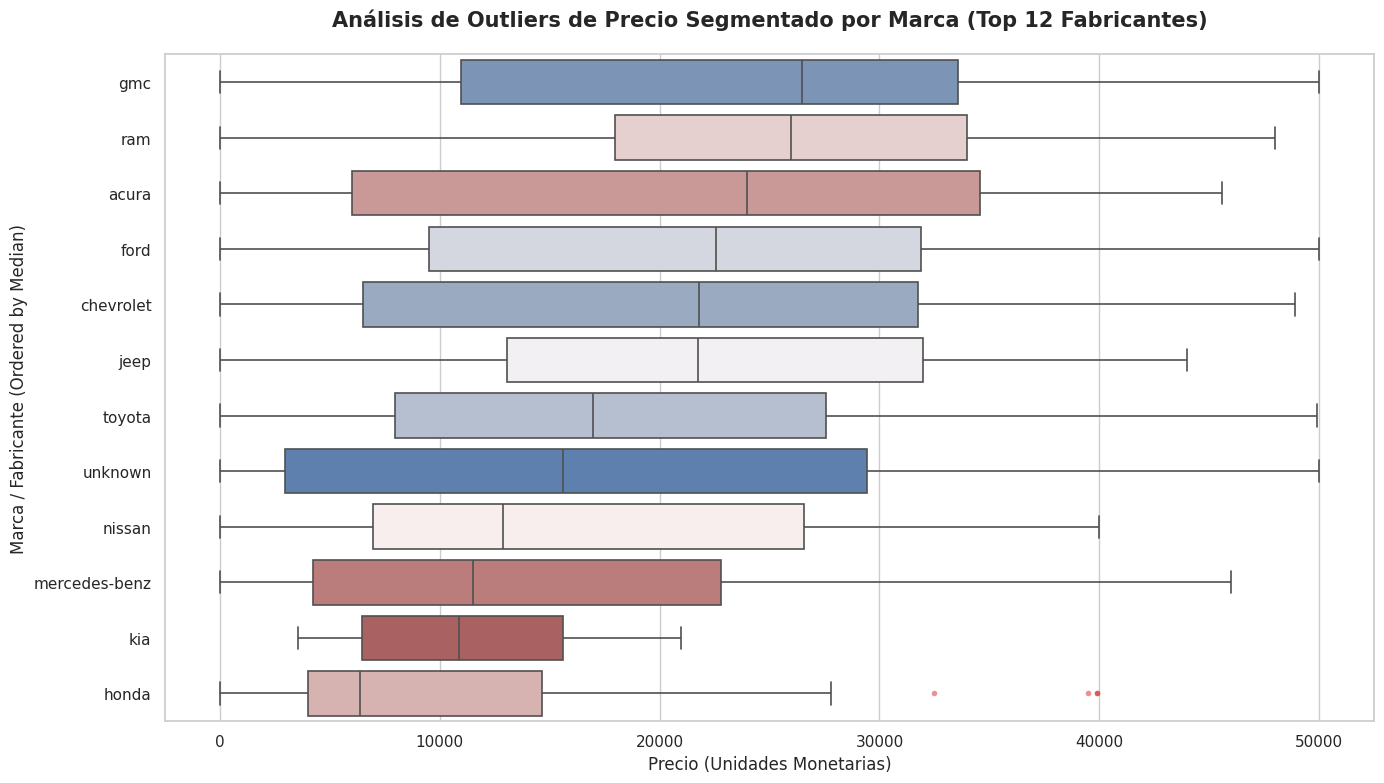

In [ ]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(14, 8))

top_marcas = df['manufacturer'].value_counts().head(12).index
df_top_marcas = df[df['manufacturer'].isin(top_marcas)].copy()

limite_visual = df_top_marcas['price'].quantile(0.98)
df_visualizacion = df_top_marcas[df_top_marcas['price'] <= limite_visual]

orden_marcas = df_visualizacion.groupby('manufacturer')['price'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_visualizacion,
    x='price',
    y='manufacturer',
    order=orden_marcas,
    palette='vlag',
    fliersize=4,
    flierprops={
        'markerfacecolor': '#d62728',
        'marker': 'o',
        'alpha': 0.5,
        'markeredgecolor': 'none'
    },
    linewidth=1.2,
    hue='manufacturer',
    legend=False
)

plt.title('Análisis de Outliers de Precio Segmentado por Marca (Top 12 Fabricantes)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Precio (Unidades Monetarias)', fontsize=12)
plt.ylabel('Marca / Fabricante (Ordered by Median)', fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('grafico5.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Este grafico nos permite hacer un análisis comparativo avanzado de cómo se distribuyen los precios dentro de cada marca y mapear con precisión quirúrgica dónde están los verdaderos valores atípicos. Demuestra que un precio de 40,000 dolares es perfectamente normal e interno para una camioneta Ram o un BMW, pero es un valor atípico radical si estás analizando un Honda o un Nissan.

####Mapa de calor de correlación: Valores numéricos frente a precios

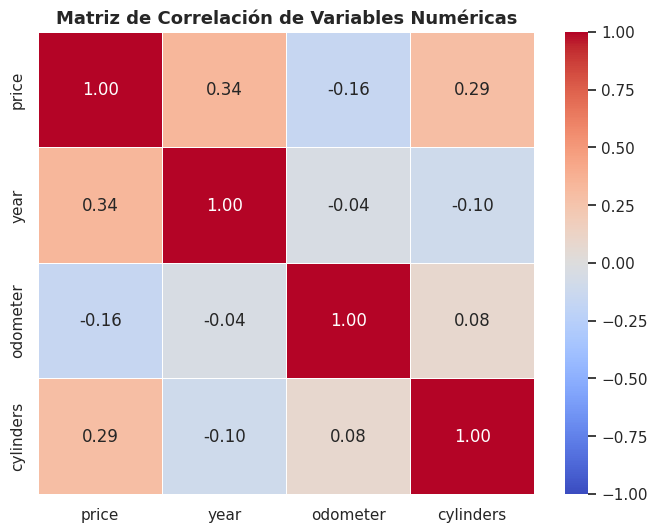

In [ ]:
fig = plt.figure(figsize=(8, 6))

# Seleccionamos solo las variables numéricas clave
columnas_numericas = ['price', 'year', 'odometer', 'cylinders']
matriz_corr = df[columnas_numericas].corr(method='pearson')

# Dibujar el heatmap
sns.heatmap(
    matriz_corr,
    annot=True,          # Coloca el valor numérico de la correlación en cada celda
    cmap='coolwarm',     # Escala de color de azul (negativa) a rojo (positiva)
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1      # Fuerza los límites estadísticos de la correlación
)

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=13, fontweight='bold')
plt.show()

fig.savefig('grafico6.png', dpi=300, bbox_inches='tight')
plt.close(fig)

EL HeatMap muestra que precio y año de fabricacion tienen una correlacion debil - moderada positiva, ya que muestra que a medida que el año del vehículo aumenta (es decir, el auto es más nuevo), el precio tiende a subir. Esto concuerda perfectamente con la lógica de mercado que vimos en la primera gráfica (curva de depreciación).
de igual media el precio y cilindrada presenta una correlacion debil positiva que indica que los vehículos con mayor número de cilindros (motores más grandes como V6 o V8) tienden a ser más costosos que los de 3 o 4 cilindros. Esto amarra muy bien con lo que descubrimos en el gráfico de marcas, donde las marcas que venden camionetas grandes (ram y gmc) tenían los precios medianos más altos.

####Grafico de Dispersion - Precio vs. Potencia, según el tipo de combustible

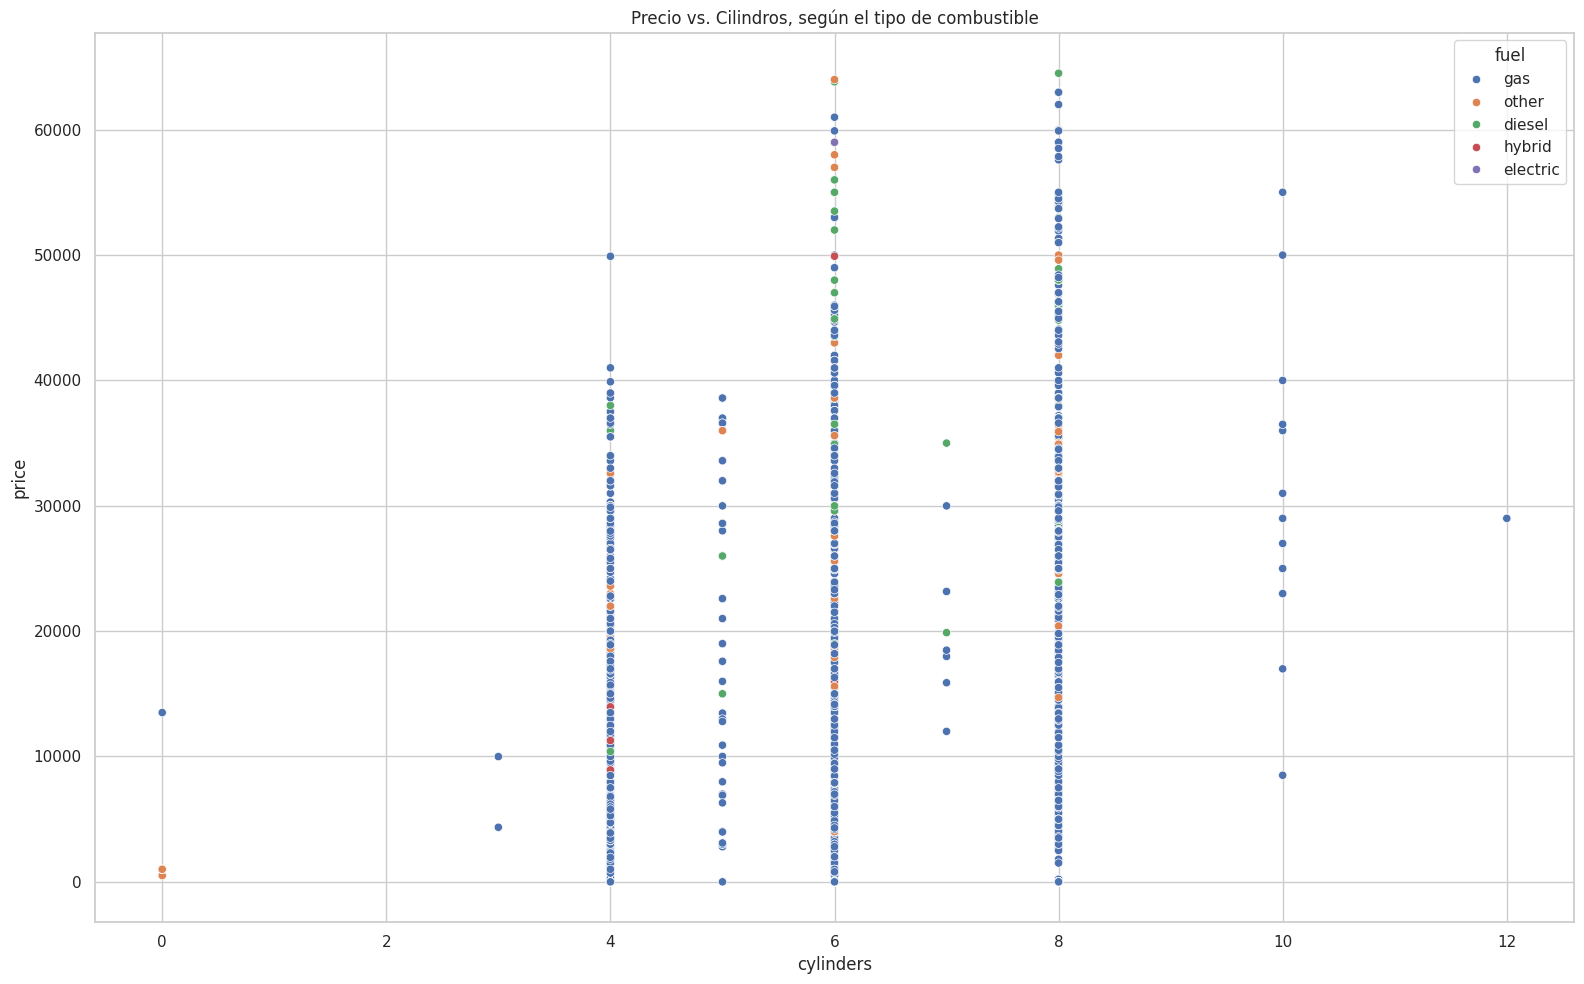

In [ ]:
fig = plt.figure(figsize=(16, 10))

ax2 = fig.add_subplot()
sns.scatterplot(data=df, x='cylinders', y='price',
                hue='fuel',
                 sizes=(20, 200), ax=ax2)
ax2.set_title("Precio vs. Cilindros, según el tipo de combustible")


plt.tight_layout()
plt.show()

fig.savefig('grafico7.png', dpi=300, bbox_inches='tight')
plt.close(fig)

El gráfico muestra columnas verticales muy densas de puntos agrupados. Las columnas con mayor volumen de datos (donde los puntos están más apretados) corresponden a 4, 6 y 8 cilindros. Esto refleja fielmente la realidad del parque automotriz. Los motores de 4 cilindros (autos medianos/compactos), 6 cilindros (SUVs y sedanes grandes) y 8 cilindros (camionetas pesadas y deportivos) dominan el mercado de usados. Las configuraciones de 1, 2, 9 o 10 cilindros son exóticas o extremadamente raras en la muestra.

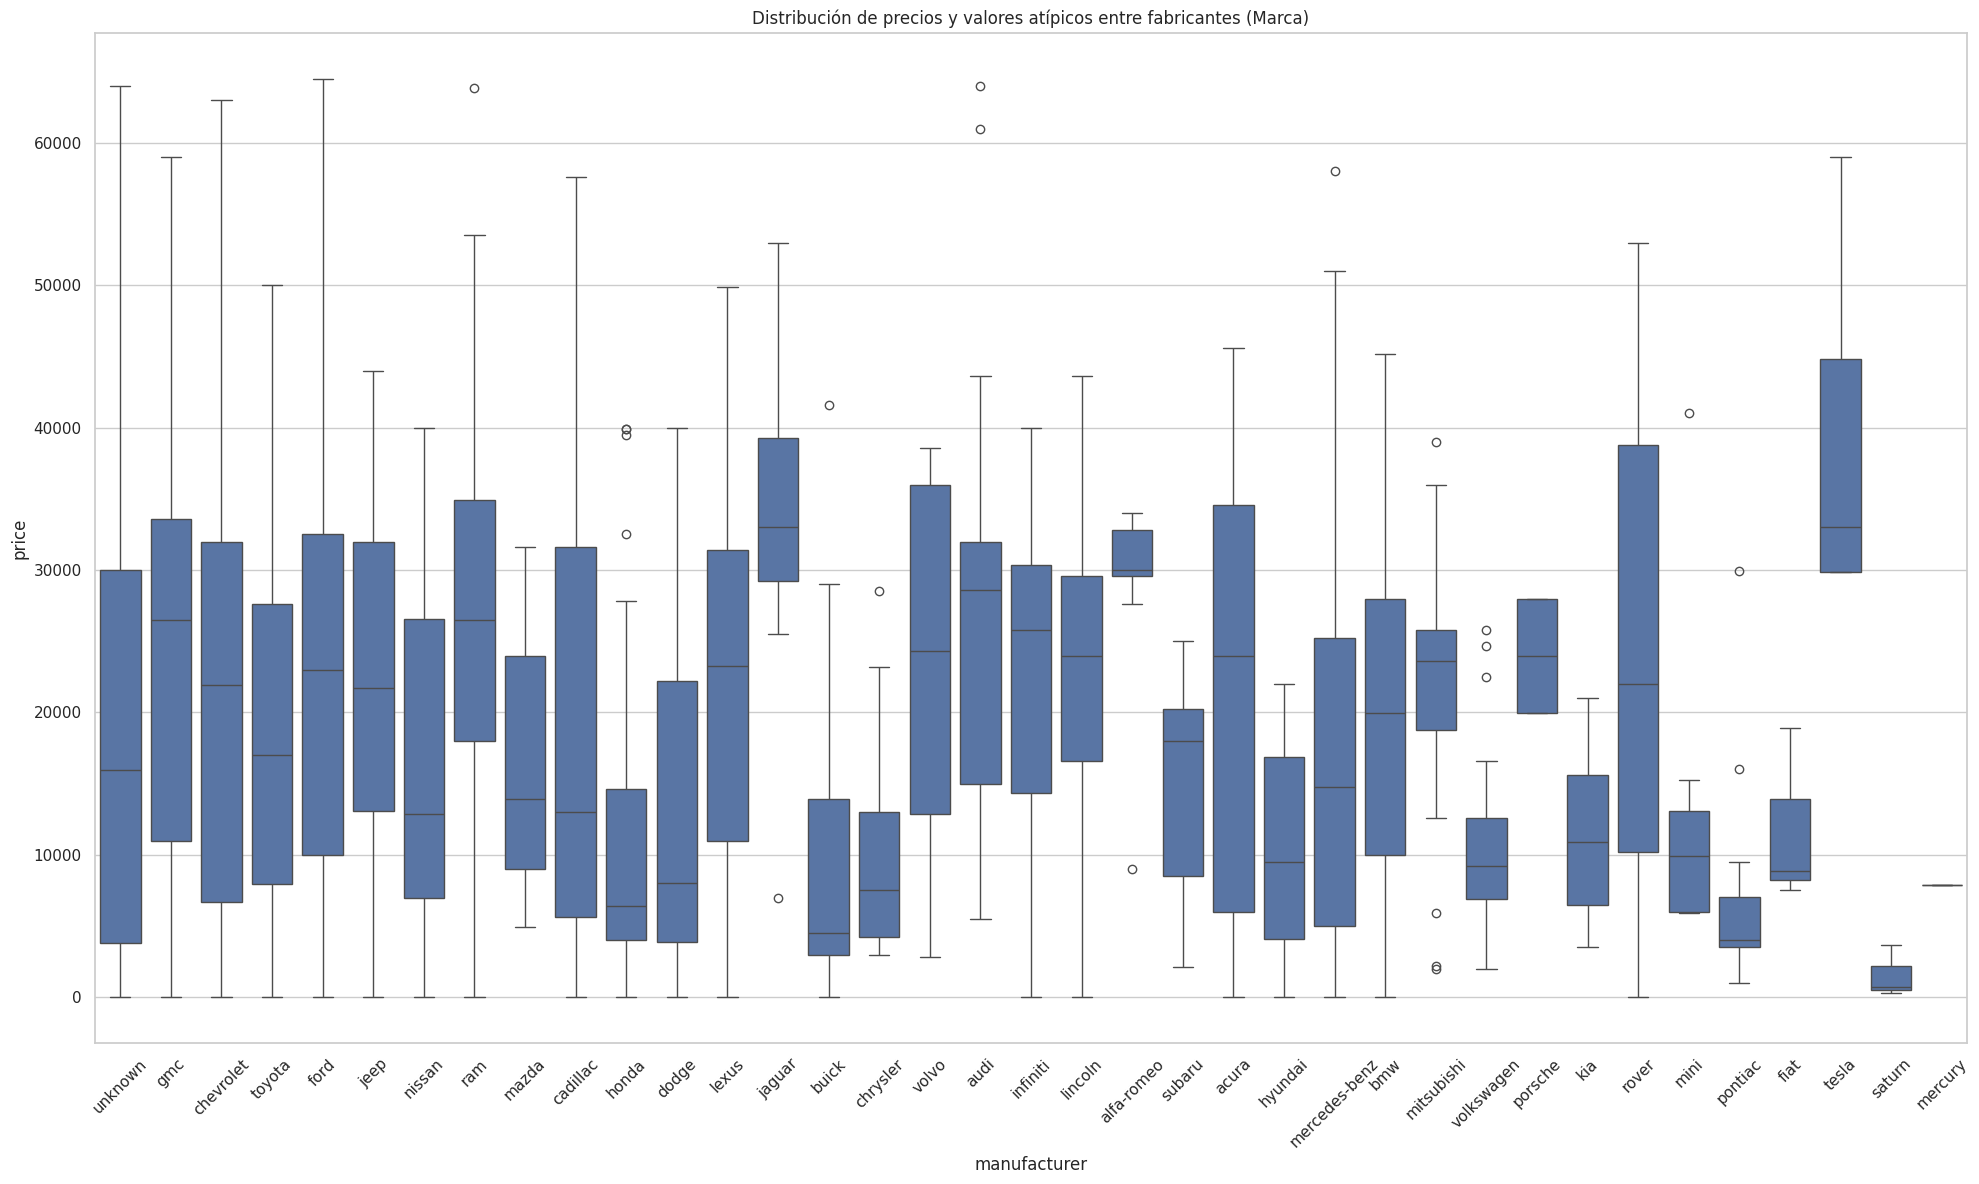

In [ ]:
fig = plt.figure(figsize=(20, 12))

ax3 = fig.add_subplot()
sns.boxplot(data=df, x='manufacturer', y='price', ax=ax3)
ax3.set_title("Distribución de precios y valores atípicos entre fabricantes (Marca)")
plt.xticks(rotation=45) # Rotar etiquetas si hay muchas marcas

plt.tight_layout()
plt.show()
fig.savefig('grafico8.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Este gráfico es el argumento definitivo que demuestra que no se puede hacer un análisis de Machine Learning con este dataset sin una etapa de correccion de la data en la cual se plantean los siguiente puntos a corregir.

* corregir los datos de cilindraje donde el valor es 0 y reemplazarlo con el valor electric.
* Eliminar marcas baja representatividad: Marcas como Ferrari o Morgan deberían ser removidas del modelo general porque tienen tan pocos datos que solo aportan ruido e interpretaciones erróneas.
* aplicar un filtro inferior (por ejemplo, price > 500) para limpiar todos esos círculos y bases de cajas que están tocando el cero de forma errónea en prácticamente todas las marcas.

###Limpieza Post Analisis Grafico

#### Correcion inconcistencia en el cilindraje

In [ ]:
df['cylinders'] = df['cylinders'].astype(str)

# Limpiamos posibles decimales que Pandas agrega al convertir (ej: "0.0" -> "0")
df['cylinders'] = df['cylinders'].str.replace('.0', '', regex=False)

# Reemplazamos el valor '0' por 'electric'
df['cylinders'] = df['cylinders'].replace('0', 'electric')

# Verificar los cambios y los tipos de datos resultantes
print(df['cylinders'].unique())
print(df['cylinders'].dtype)

['6' '8' '4' '5' 'electric' '7' '3' '10' '12']
object


####Eliminacion de Vehiculos con valores atipicos

In [ ]:
umbral_minimo = 50

# Calcular la frecuencia (conteo) de cada marca
conteos_por_marca = df['manufacturer'].value_counts()

# Filtrar cuáles son las marcas que quedan por debajo del umbral
marcas_a_eliminar = conteos_por_marca[conteos_por_marca < umbral_minimo].index.tolist()

# Eliminar esas marcas del DataFrame general
df_filtrado = df[~df['manufacturer'].isin(marcas_a_eliminar)].copy()

# --- Bloque de Control y Auditoría ---
print(f"Marcas eliminadas por baja representatividad (< {umbral_minimo} registros):")
print(marcas_a_eliminar)
print(f"\nDimensiones originales: {df.shape}")
print(f"Dimensiones tras el filtrado: {df_filtrado.shape}")
df = df_filtrado.copy()


Marcas eliminadas por baja representatividad (< 50 registros):
['volvo', 'lincoln', 'audi', 'chrysler', 'mazda', 'mitsubishi', 'volkswagen', 'subaru', 'alfa-romeo', 'jaguar', 'pontiac', 'rover', 'tesla', 'mini', 'porsche', 'fiat', 'saturn', 'mercury']

Dimensiones originales: (3346, 16)
Dimensiones tras el filtrado: (2978, 16)


#### Eliminacion registros con valor inferior a 500 Dolares.

In [ ]:
precio_minimo = 500

# Guardar el número de filas actual para la auditoría
filas_antes = df.shape[0]

# Aplicar el filtro: mantener solo los vehículos con precio estrictamente mayor al mínimo
df_limpio = df[df['price'] > precio_minimo].copy()

# Calcular cuántos registros eran "ruido"
filas_despues = df_limpio.shape[0]
registros_eliminados = filas_antes - filas_despues

# --- Bloque de Control y Auditoría ---
print("--- Reporte de Limpieza de Precios ---")
print(f"Registros analizados inicialmente: {filas_antes}")
print(f"Registros eliminados (Precios <= {precio_minimo}): {registros_eliminados}")
print(f"Registros limpios disponibles: {filas_despues}")
print(f"Porcentaje de ruido eliminado: {(registros_eliminados / filas_antes) * 100:.2f}%")

df = df_limpio.copy()

--- Reporte de Limpieza de Precios ---
Registros analizados inicialmente: 2978
Registros eliminados (Precios <= 500): 203
Registros limpios disponibles: 2775
Porcentaje de ruido eliminado: 6.82%


##Preprocesamiento DataSet

In [ ]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'paint_color', 'state', 'posting_date'],
      dtype='object')

In [ ]:
df.dtypes

,0
region,object
price,int64
year,float64
manufacturer,object
model,object
condition,object
cylinders,object
fuel,object
odometer,int64
title_status,object


Importe Libreria SKlearn

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

###Separacion features y Target

In [ ]:
X = df.drop(columns=['price', 'posting_date'])
y = df['price']

###Deteccion de Columnas


In [ ]:
print(df.dtypes)

region                             object
price                               int64
year                              float64
manufacturer                       object
model                              object
condition                          object
cylinders                          object
fuel                               object
odometer                            int64
title_status                       object
transmission                       object
drive                              object
type                               object
paint_color                        object
state                              object
posting_date    datetime64[ns, UTC-05:00]
dtype: object


In [ ]:
numeric_features = list(X.select_dtypes(include=['float64', 'int' ]).columns)
categorical_features = list(X.select_dtypes(include=['object', 'category']).columns)

print(f'Categóricas ({len(categorical_features)}): {categorical_features}')
print(f'Numéricas ({len(numeric_features)}): {numeric_features}')

Categóricas (12): ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Numéricas (2): ['year', 'odometer']


###Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')


Train: (2220, 14)  |  Test: (555, 14)


###Column Transformer Numerico

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


###Column Transformer Categorico

In [ ]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])


###Column Transform Preprocesamiento

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
],
                                 remainder='passthrough'
)


In [ ]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'odometer']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['region', 'manufacturer', 'model',
                                  'condition', 'cylinders', 'fuel',
                                  'title_status', 'transmission', 'drive',
                                  'type', 'paint_color', 'state'])])

##Entrenamiento de Modelos

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f'Shape tras preprocesar — train: {X_train_prep.shape}')
print(f'Features generadas: {X_train_prep.shape[1]} (desde {X_train.shape[1]} columnas originales)')



Shape tras preprocesar — train: (2220, 913)
Features generadas: 913 (desde 14 columnas originales)


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor # Explicitly import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import pandas as pd # Import pandas for DataFrame creation
import numpy as np  # Import numpy for sqrt

modelos = {
    'Regresion Lineal':      LinearRegression(),
    'RandomForest(200)': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
}



##Metricas

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train_prep, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test_prep)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),

        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
RandomForest(200),0.8782,2996.8721,4490.0798,6.16,0.044
Regresion Lineal,-0.3301,7330.6507,14836.3044,0.23,0.000


##Metricas

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train_prep, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test_prep)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'MSE':        mean_squared_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,MSE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,,
RandomForest(200),0.8782,2996.8721,2.016082e+07,4490.0798,3.79,0.033
Regresion Lineal,-0.3301,7330.6507,2.201159e+08,14836.3044,0.11,0.000


##Hiperparametros Con GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir el modelo base + grilla de hiperparámetros a probar
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [390,400,410],
    'max_depth':    [25,26,27,28]
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
import numpy as np  # Import numpy for sqrt
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

print('Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...')
grid.fit(X_train_prep, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test_prep, y_test):.4f}')

Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

🏆 Mejores hiperparámetros: {'max_depth': 27, 'n_estimators': 410}
   Mejor R² (CV):           0.8202
   R² en test:              0.8865


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor # Explicitly import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import pandas as pd # Import pandas for DataFrame creation
import numpy as np  # Import numpy for sqrt

modelos = {
    'RandomForest(200)': RandomForestRegressor(n_estimators=410, max_depth=27, n_jobs=-1, random_state=42),
}




In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train_prep, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test_prep)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'MSE':        mean_squared_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,MSE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,,
RandomForest(200),0.8865,2659.2695,1.878541e+07,4334.2136,25.68,0.127


In [ ]:
try:
    from lazypredict.Supervised import LazyRegressor
    reg = LazyRegressor(verbose=0, ignore_warnings=True)
    # X_train_prep and X_test_prep are already dense numpy arrays, no need to call .toarray()
    modelos_lazy, _ = reg.fit(X_train_prep.toarray(), X_test_prep.toarray(), y_train, y_test)
    print('Top 10 modelos por R²:')
    display(modelos_lazy.head(10))
except ImportError:
    print('⚠️ LazyPredict no instalado. Corre: !pip install lazypredict')

Top 10 modelos por R²:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
SGDRegressor,206295.504674,-133680.818011,4.703496e+06,0.148569
GaussianProcessRegressor,601.568514,-388.177070,2.537805e+05,9.155048
PoissonRegressor,113.791474,-72.090504,1.099804e+05,0.805758
KernelRidge,6.736628,-2.717418,2.480306e+04,0.528391
LinearSVR,5.714202,-2.054871,2.248439e+04,0.236290
TransformedTargetRegressor,3.069518,-0.341078,1.489744e+04,0.524621
LinearRegression,3.069518,-0.341078,1.489744e+04,2.643519
MLPRegressor,2.895105,-0.228055,1.425587e+04,10.849026
NuSVR,2.547524,-0.002818,1.288237e+04,2.138857


In [ ]:
modelos_lazy

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
SGDRegressor,206295.504674,-133680.818011,4.703496e+06,0.148569
GaussianProcessRegressor,601.568514,-388.177070,2.537805e+05,9.155048
PoissonRegressor,113.791474,-72.090504,1.099804e+05,0.805758
KernelRidge,6.736628,-2.717418,2.480306e+04,0.528391
LinearSVR,5.714202,-2.054871,2.248439e+04,0.236290
TransformedTargetRegressor,3.069518,-0.341078,1.489744e+04,0.524621
LinearRegression,3.069518,-0.341078,1.489744e+04,2.643519
MLPRegressor,2.895105,-0.228055,1.425587e+04,10.849026
NuSVR,2.547524,-0.002818,1.288237e+04,2.138857


##Conclusiones

El entrenamiento de los modelos arrojo los isguientes resultados
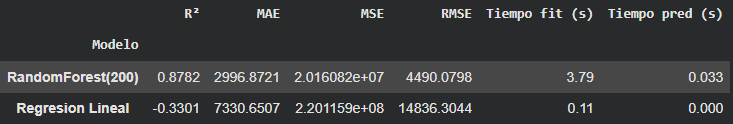

los hiperparametro selecionador por gridSearchCV y  aplicados Ramdom Forest arrojaron los siguientes resultados

In [ ]:
tabla

,R²,MAE,MSE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,,
RandomForest(200),0.8865,2659.2695,1.878541e+07,4334.2136,25.68,0.127


En estricto rigor los resultados de los modelos indica que la regresión lineal no sirve para estos datos ya que se genera un underfitting, el hecho de obtener un coeficiente de determinación negativo (-0,330), responde a que variables predictoras y la variable target no se puede estimar de forma lineal (no lineal). Aunque Ramdom Forest obtiene un coeficiente de determinación mucho mayor (0,878) aun así comete grandes errores visibles en el RMSE (4490 dolares) lo cual indica que aun hay datos que pueden ser considerados como outliers que generan esta penalización sobre los residuos.


La optimización planteada por GridSearchCV genera una mejor mínima sobre Random Forest obteniendo un punto porcentual mas y disminuyendo el RMSE pero aun así, este aun sigue siendo demasiado alto.


Por lo cual se recomienda volver a tratar el dataset y aplicar una técnica de limpieza más agresiva, para lograr errores más pequeños y que sean aceptables en l aprediccion. Así también realizar ingeniería de features que puedan aporta al entrenamiento de los modelos.


El uso de LazyPredict confirma que  el uso de Random Forest es una de la mejores opciones para los datos y refuerza  la aplicación de una técnica de limpieza mas agresiva.
